# Audio Gate — Промежуточная оценка полезности аудио

Идея: обучить временную «глупую» модель, прогнать её с аудио и без,
определить per-sample полезность аудио, и передать этот сигнал (0/1) основному классификатору.

## Этапы

| Этап | Что делаем |
|------|------------|
| 1 | Загружаем данные (из stage3) |
| 2 | Обучаем «глупую» временную модель **без аудио** (только RGB) |
| 3 | Обучаем ту же модель **с аудио** |
| 4 | Per-sample: аудио помогло? → метка `audio_useful` |
| 5 | Gate-сеть: `audio → audio_useful` |
| 6 | Gated классификатор: `RGB + gate*audio + gate_scalar` |
| 7 | Сравнение: baseline vs gated |

In [15]:
# ============================================================
# 0 — Импорты и конфиг
# ============================================================
import numpy as np
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'device: {DEVICE}')

device: cuda


In [16]:
# ============================================================
# 1 — Загрузка данных из stage3
# ============================================================
# Пробуем сначала локальный путь, потом ClearML
_local_processed = Path('../data2/frame_processed')
_local_splits    = Path('../data2/frame_stage3')

if _local_processed.exists() and _local_splits.exists():
    SRC_DIR    = _local_processed
    STAGE3_DIR = _local_splits
    print(f'✓ Local: {SRC_DIR}')
else:
    from clearml import Dataset as ClearMLDataset
    SRC_DIR = Path(ClearMLDataset.get(
        dataset_name='yt8m-frame-processed',
        dataset_project='YT8M Video Classifier',
    ).get_local_copy())
    STAGE3_DIR = Path(ClearMLDataset.get(
        dataset_name='yt8m-frame-splits',
        dataset_project='YT8M Video Classifier',
    ).get_local_copy())
    print(f'✓ ClearML: {SRC_DIR}')

cfg       = json.load(open(SRC_DIR / 'config.json'))
L         = cfg['L']
DIM_RGB   = cfg['dim_rgb']
DIM_AUD   = cfg['dim_audio']
DEQ_S     = cfg['dequant_scale']
DEQ_B     = cfg['dequant_bias']
GENRES    = cfg['genres']
N_CLASSES = cfg['n_classes']

X_rgb_q   = np.load(SRC_DIR / 'X_rgb.npy',   mmap_mode='r')
X_audio_q = np.load(SRC_DIR / 'X_audio.npy', mmap_mode='r')
lengths   = np.load(SRC_DIR / 'lengths.npy')
y         = np.load(SRC_DIR / 'y.npy')

idx_train = np.load(STAGE3_DIR / 'idx_train.npy')
idx_val   = np.load(STAGE3_DIR / 'idx_val.npy')
idx_test  = np.load(STAGE3_DIR / 'idx_test.npy')

norm      = np.load(STAGE3_DIR / 'norm_stats.npz')
rgb_mean, rgb_std = norm['rgb_mean'], norm['rgb_std']
aud_mean, aud_std = norm['aud_mean'], norm['aud_std']

print(f'N={len(y):,}  L={L}  dim_rgb={DIM_RGB}  dim_audio={DIM_AUD}  n_classes={N_CLASSES}')
print(f'Train={len(idx_train):,}  Val={len(idx_val):,}  Test={len(idx_test):,}')

✓ Local: ../data2/frame_processed
N=4,939  L=60  dim_rgb=1024  dim_audio=128  n_classes=12
Train=3,457  Val=741  Test=741


In [17]:
# ============================================================
# 2 — Dataset: поддерживает режим «без аудио» (use_audio=False)
# ============================================================
class FrameDataset(Dataset):
    def __init__(self, rgb_q, aud_q, lengths, y, indices,
                 rgb_mean, rgb_std, aud_mean, aud_std,
                 deq_s, deq_b, use_audio=True):
        self.rgb_q    = rgb_q
        self.aud_q    = aud_q
        self.lengths  = lengths
        self.y        = y
        self.indices  = np.asarray(indices, dtype=np.int64)
        self.rgb_mean = rgb_mean.astype(np.float32)
        self.rgb_std  = rgb_std.astype(np.float32)
        self.aud_mean = aud_mean.astype(np.float32)
        self.aud_std  = aud_std.astype(np.float32)
        self.deq_s    = deq_s
        self.deq_b    = deq_b
        self.use_audio = use_audio

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        T   = int(self.lengths[idx])

        rgb = np.asarray(self.rgb_q[idx], dtype=np.float32) * self.deq_s + self.deq_b
        aud = np.asarray(self.aud_q[idx], dtype=np.float32) * self.deq_s + self.deq_b

        rgb[:T] = (rgb[:T] - self.rgb_mean) / self.rgb_std
        rgb[T:] = 0.0

        if self.use_audio:
            aud[:T] = (aud[:T] - self.aud_mean) / self.aud_std
            aud[T:] = 0.0
        else:
            aud[:] = 0.0   # ← режим «без аудио»

        return (torch.from_numpy(rgb),
                torch.from_numpy(aud),
                torch.tensor(T, dtype=torch.long),
                torch.tensor(int(self.y[idx]), dtype=torch.long))


def make_loaders(use_audio=True, batch_size=256):
    kw = dict(
        rgb_q=X_rgb_q, aud_q=X_audio_q, lengths=lengths, y=y,
        rgb_mean=rgb_mean, rgb_std=rgb_std,
        aud_mean=aud_mean, aud_std=aud_std,
        deq_s=DEQ_S, deq_b=DEQ_B, use_audio=use_audio,
    )
    tr = DataLoader(FrameDataset(indices=idx_train, **kw),
                    batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    va = DataLoader(FrameDataset(indices=idx_val,   **kw),
                    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(FrameDataset(indices=idx_test,  **kw),
                    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return tr, va, te

print('Dataset OK')

Dataset OK


In [18]:
# ============================================================
# 3 — «Глупая» временная модель (маленький GRU)
# ============================================================
# Не нужна высокая точность — нужно только выявить, помогает ли аудио.
# Специально берём маленькую: rnn_hidden=64, proj=64.

class TinyRNN(nn.Module):
    """Маленький GRU-классификатор. Тот же интерфейс что FrameRNN из stage4."""
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=64, rnn_hidden=64, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim_rgb + dim_aud, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )
        self.rnn = nn.GRU(proj_dim, rnn_hidden, batch_first=True, bidirectional=True)
        out_dim  = rnn_hidden * 2
        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, rgb, aud, lengths):
        x = self.proj(torch.cat([rgb, aud], dim=-1))
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed   = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)           # hidden: (2, B, H)
        h = torch.cat([hidden[-2], hidden[-1]], dim=-1)   # (B, 2H)
        return self.head(h)


def build_tiny():
    return TinyRNN(DIM_RGB, DIM_AUD, N_CLASSES).to(DEVICE)

nparams = sum(p.numel() for p in build_tiny().parameters())
print(f'TinyRNN params: {nparams/1e3:.1f}K')

TinyRNN params: 125.6K


In [19]:
# ============================================================
# 4 — Обучение временной модели (один цикл)
# ============================================================
def train_model(model, tr_loader, va_loader, epochs=10, lr=3e-4, label=''):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_val = 0.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        for rgb, aud, T, yi in tr_loader:
            rgb, aud, T, yi = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE), yi.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(rgb, aud, T), yi)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for rgb, aud, T, yi in va_loader:
                rgb, aud, T = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE)
                p = model(rgb, aud, T).argmax(1).cpu().numpy()
                preds.extend(p); trues.extend(yi.numpy())
        val_acc = accuracy_score(trues, preds)

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if ep % 5 == 0:
            print(f'  [{label}] ep {ep:>2}/{epochs}  val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    print(f'  [{label}] best val_acc={best_val:.4f}')
    return best_val


EPOCHS = 15

# ── Модель БЕЗ аудио
tr_no,  va_no,  te_no  = make_loaders(use_audio=False)
model_no_audio = build_tiny()
print('=== Модель БЕЗ аудио ===')
acc_no_audio = train_model(model_no_audio, tr_no, va_no, epochs=EPOCHS, label='no_audio')

# ── Модель С аудио
tr_yes, va_yes, te_yes = make_loaders(use_audio=True)
model_with_audio = build_tiny()
print('\n=== Модель С аудио ===')
acc_with_audio = train_model(model_with_audio, tr_yes, va_yes, epochs=EPOCHS, label='with_audio')

print(f'\nИтог: без аудио={acc_no_audio:.4f}  с аудио={acc_with_audio:.4f}')
print(f'Разница: {acc_with_audio - acc_no_audio:+.4f}')

=== Модель БЕЗ аудио ===
  [no_audio] ep  5/15  val_acc=0.4440
  [no_audio] ep 10/15  val_acc=0.5439
  [no_audio] ep 15/15  val_acc=0.5601
  [no_audio] best val_acc=0.5601

=== Модель С аудио ===
  [with_audio] ep  5/15  val_acc=0.5412
  [with_audio] ep 10/15  val_acc=0.6235
  [with_audio] ep 15/15  val_acc=0.6329
  [with_audio] best val_acc=0.6329

Итог: без аудио=0.5601  с аудио=0.6329
Разница: +0.0729


In [20]:
# ============================================================
# 5 — Per-sample: помогло ли аудио?
# ============================================================
# Для каждого сэмпла в train-сете смотрим:
#   - модель БЕЗ аудио угадала верно? → correct_no
#   - модель С аудио угадала верно?   → correct_yes
# audio_useful = 1 если (correct_yes AND NOT correct_no)
# audio_useful = 0 если (NOT correct_yes AND correct_no)  — аудио мешает
# остальные случаи → оба угадали / оба не угадали (берём нейтральное 0)
#
# TRAIN используется и для gate-сети — val/test не трогаем (честность).

def get_preds_and_labels(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for rgb, aud, T, yi in loader:
            rgb, aud, T = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE)
            p = model(rgb, aud, T).argmax(1).cpu().numpy()
            preds.extend(p); trues.extend(yi.numpy())
    return np.array(preds), np.array(trues)


# Прогоняем по train (без shuffle, batch_size=512 для скорости)
def make_eval_loader(use_audio, indices, batch_size=512):
    kw = dict(
        rgb_q=X_rgb_q, aud_q=X_audio_q, lengths=lengths, y=y,
        rgb_mean=rgb_mean, rgb_std=rgb_std,
        aud_mean=aud_mean, aud_std=aud_std,
        deq_s=DEQ_S, deq_b=DEQ_B, use_audio=use_audio,
    )
    return DataLoader(FrameDataset(indices=indices, **kw),
                      batch_size=batch_size, shuffle=False, num_workers=2)


p_no,  true_tr = get_preds_and_labels(model_no_audio,   make_eval_loader(False, idx_train))
p_yes, _       = get_preds_and_labels(model_with_audio, make_eval_loader(True,  idx_train))

correct_no  = (p_no  == true_tr)
correct_yes = (p_yes == true_tr)

# 1 = аудио помогло, 0 = не помогло / безразлично / мешало
audio_useful = ((correct_yes) & (~correct_no)).astype(np.int64)

n_helpful    = audio_useful.sum()
n_harmful    = ((~correct_yes) & (correct_no)).sum()
n_both_right = (correct_no & correct_yes).sum()
n_both_wrong = (~correct_no & ~correct_yes).sum()

print(f'Train size: {len(idx_train):,}')
print(f'  аудио помогло (1→1, 0→1): {n_helpful:>6} ({100*n_helpful/len(idx_train):.1f}%)')
print(f'  аудио помешало (1→0):     {n_harmful:>6} ({100*n_harmful/len(idx_train):.1f}%)')
print(f'  оба правы:                {n_both_right:>6} ({100*n_both_right/len(idx_train):.1f}%)')
print(f'  оба неправы:              {n_both_wrong:>6} ({100*n_both_wrong/len(idx_train):.1f}%)')
print(f'\n  gate_positive_rate = {n_helpful/len(idx_train):.4f}')

Train size: 3,457
  аудио помогло (1→1, 0→1):    194 (5.6%)
  аудио помешало (1→0):         76 (2.2%)
  оба правы:                  3120 (90.3%)
  оба неправы:                  67 (1.9%)

  gate_positive_rate = 0.0561


In [21]:
# ============================================================
# 6 — Gate-Dataset: аудио-признаки → audio_useful (0/1)
# ============================================================
# Берём mean pooling аудио по реальным кадрам как признак для gate-сети.
# gate-сеть не видит видео — только аудио.

def extract_audio_repr(indices, audio_useful_labels=None):
    """Возвращает (audio_mean_pool [N, DIM_AUD], labels [N])"""
    feats = []
    for idx in indices:
        T   = int(lengths[idx])
        aud = np.asarray(X_audio_q[idx, :T], dtype=np.float32) * DEQ_S + DEQ_B
        aud = (aud - aud_mean) / aud_std
        feats.append(aud.mean(axis=0))   # mean pool → (DIM_AUD,)
    return np.stack(feats), audio_useful_labels


X_gate_train, y_gate_train = extract_audio_repr(idx_train, audio_useful)
print(f'Gate train: X={X_gate_train.shape}  pos={y_gate_train.sum()}/{len(y_gate_train)}')

# Аудио-представление для val/test (метки не нужны для gate-обучения,
# но нужны для финальной оценки)
X_gate_val,  _ = extract_audio_repr(idx_val)
X_gate_test, _ = extract_audio_repr(idx_test)
print(f'Gate val:   X={X_gate_val.shape}')
print(f'Gate test:  X={X_gate_test.shape}')

Gate train: X=(3457, 128)  pos=194/3457
Gate val:   X=(741, 128)
Gate test:  X=(741, 128)


In [22]:
# ============================================================
# 7 — Gate-сеть: маленький MLP (аудио → вероятность полезности)
# ============================================================
class AudioGateNet(nn.Module):
    """Бинарный классификатор: аудио → P(audio_useful).
       На выходе sigmoid → скаляр ∈ (0,1).
       Порог 0.5 → binary gate (0/1)."""
    def __init__(self, dim_aud, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_aud, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)   # logits (B,)

    def predict_gate(self, x, threshold=0.5):
        with torch.no_grad():
            prob = torch.sigmoid(self.forward(x))
        return (prob >= threshold).float()   # 0.0 или 1.0


gate_net = AudioGateNet(DIM_AUD).to(DEVICE)
print(f'AudioGateNet params: {sum(p.numel() for p in gate_net.parameters()):,}')

# ── Dataloaders для gate
from torch.utils.data import TensorDataset

def make_gate_loader(X, y_g=None, batch_size=512, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y_g is not None:
        yt = torch.tensor(y_g, dtype=torch.float32)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size, shuffle=False)


gl_tr = make_gate_loader(X_gate_train, y_gate_train, shuffle=True)
gl_va = make_gate_loader(X_gate_val)

# ── Обучение gate-сети
pos_weight = torch.tensor([(y_gate_train == 0).sum() / (y_gate_train == 1).sum() + 1e-6]).to(DEVICE)
g_opt   = torch.optim.Adam(gate_net.parameters(), lr=1e-3, weight_decay=1e-4)
g_crit  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

for ep in range(1, 21):
    gate_net.train()
    for Xb, yb in gl_tr:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        g_opt.zero_grad()
        g_crit(gate_net(Xb), yb).backward()
        g_opt.step()

    if ep % 5 == 0:
        gate_net.eval()
        with torch.no_grad():
            Xv = torch.tensor(X_gate_val, dtype=torch.float32).to(DEVICE)
            # gate даёт вероятность; чтобы оценить качество на val,
            # нам нужны реальные метки — используем pred от train-модели на val
            g_pred = (torch.sigmoid(gate_net(Xv)) > 0.5).cpu().numpy()
        print(f'  [gate] ep {ep:>2}  gate_positive_on_val={g_pred.mean():.3f}')

print('Gate-сеть обучена.')

AudioGateNet params: 25,089
  [gate] ep  5  gate_positive_on_val=0.325
  [gate] ep 10  gate_positive_on_val=0.274
  [gate] ep 15  gate_positive_on_val=0.177
  [gate] ep 20  gate_positive_on_val=0.130
Gate-сеть обучена.


In [23]:
# ============================================================
# 8 — Gated Dataset: audio *= gate, gate_scalar как доп. признак
# ============================================================
# Gate-сеть предсказывает для каждого видео: нужно ли слушать аудио.
# Используем мягкий gate (sigmoid, float 0–1) — это дифференцируемо.
#
# Для финального классификатора добавляем скаляр gate как доп. признак:
#   вход = [rgb, aud * gate, gate]  → всё в concat перед GRU

class GatedFrameDataset(Dataset):
    """Как FrameDataset, но audio *= gate_value (float)."""
    def __init__(self, rgb_q, aud_q, lengths, y, indices,
                 rgb_mean, rgb_std, aud_mean, aud_std,
                 deq_s, deq_b, gate_values):
        self.rgb_q     = rgb_q
        self.aud_q     = aud_q
        self.lengths   = lengths
        self.y         = y
        self.indices   = np.asarray(indices, dtype=np.int64)
        self.rgb_mean  = rgb_mean.astype(np.float32)
        self.rgb_std   = rgb_std.astype(np.float32)
        self.aud_mean  = aud_mean.astype(np.float32)
        self.aud_std   = aud_std.astype(np.float32)
        self.deq_s     = deq_s
        self.deq_b     = deq_b
        self.gate_vals = gate_values.astype(np.float32)   # (N,) уже 0/1 или sigmoid

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        T   = int(self.lengths[idx])
        g   = float(self.gate_vals[i])

        rgb = np.asarray(self.rgb_q[idx], dtype=np.float32) * self.deq_s + self.deq_b
        aud = np.asarray(self.aud_q[idx], dtype=np.float32) * self.deq_s + self.deq_b

        rgb[:T] = (rgb[:T] - self.rgb_mean) / self.rgb_std
        rgb[T:] = 0.0
        aud[:T] = (aud[:T] - self.aud_mean) / self.aud_std
        aud[T:] = 0.0
        aud *= g   # ← gate: если 0.0, аудио обнулено полностью

        return (torch.from_numpy(rgb),
                torch.from_numpy(aud),
                torch.tensor(g, dtype=torch.float32),       # gate scalar
                torch.tensor(T, dtype=torch.long),
                torch.tensor(int(self.y[idx]), dtype=torch.long))


def compute_gates(gate_net, X_gate, threshold=0.5):
    gate_net.eval()
    Xt = torch.tensor(X_gate, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(gate_net(Xt)).cpu().numpy()
    return (prob >= threshold).astype(np.float32)


gates_train = compute_gates(gate_net, X_gate_train)
gates_val   = compute_gates(gate_net, X_gate_val)
gates_test  = compute_gates(gate_net, X_gate_test)

print(f'Gates train: {gates_train.mean():.3f} pos  ({int(gates_train.sum())}/{len(gates_train)})')
print(f'Gates val:   {gates_val.mean():.3f}  test: {gates_test.mean():.3f}')

Gates train: 0.143 pos  (496/3457)
Gates val:   0.130  test: 0.146


In [24]:
# ============================================================
# 9 — Финальный Gated RNN-классификатор
# ============================================================
class GatedRNN(nn.Module):
    """GRU-классификатор с audio gate.

    Вход:
      rgb    : (B, L, 1024)   — видео
      aud    : (B, L, 128)    — аудио (уже умноженное на gate)
      gate_s : (B,)           — gate scalar (0 или 1 из gate-сети)
      lengths: (B,)           — длины последовательностей

    gate_scalar добавляется к представлению перед head — классификатор
    явно знает, учитывалось ли аудио.
    """
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=128, rnn_hidden=128, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim_rgb + dim_aud, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )
        self.rnn = nn.GRU(proj_dim, rnn_hidden, batch_first=True, bidirectional=True)
        out_dim  = rnn_hidden * 2 + 1   # +1 для gate_scalar
        self.head = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, rgb, aud, gate_s, lengths):
        x = self.proj(torch.cat([rgb, aud], dim=-1))           # (B, L, proj)
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)                           # (2, B, H)
        h = torch.cat([hidden[-2], hidden[-1]], dim=-1)        # (B, 2H)
        h = torch.cat([h, gate_s.unsqueeze(1)], dim=-1)       # (B, 2H+1)
        return self.head(h)


nparams = sum(p.numel() for p in GatedRNN(DIM_RGB, DIM_AUD, N_CLASSES).parameters())
print(f'GatedRNN params: {nparams/1e3:.1f}K')

GatedRNN params: 349.6K


In [25]:
# ============================================================
# 10 — Обучение GatedRNN
# ============================================================
def make_gated_loaders(gates_train, gates_val, gates_test, batch_size=256):
    base_kw = dict(
        rgb_q=X_rgb_q, aud_q=X_audio_q, lengths=lengths, y=y,
        rgb_mean=rgb_mean, rgb_std=rgb_std,
        aud_mean=aud_mean, aud_std=aud_std,
        deq_s=DEQ_S, deq_b=DEQ_B,
    )
    tr = DataLoader(GatedFrameDataset(indices=idx_train, gate_values=gates_train, **base_kw),
                    batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    va = DataLoader(GatedFrameDataset(indices=idx_val,   gate_values=gates_val,   **base_kw),
                    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(GatedFrameDataset(indices=idx_test,  gate_values=gates_test,  **base_kw),
                    batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return tr, va, te


gated_model = GatedRNN(DIM_RGB, DIM_AUD, N_CLASSES).to(DEVICE)
g_tr, g_va, g_te = make_gated_loaders(gates_train, gates_val, gates_test)

opt   = torch.optim.Adam(gated_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
crit  = nn.CrossEntropyLoss(label_smoothing=0.05)

best_val, best_state = 0.0, None

for ep in range(1, EPOCHS + 1):
    gated_model.train()
    for rgb, aud, gs, T, yi in g_tr:
        rgb, aud, gs, T, yi = rgb.to(DEVICE), aud.to(DEVICE), gs.to(DEVICE), T.to(DEVICE), yi.to(DEVICE)
        opt.zero_grad()
        crit(gated_model(rgb, aud, gs, T), yi).backward()
        nn.utils.clip_grad_norm_(gated_model.parameters(), 1.0)
        opt.step()
    sched.step()

    gated_model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for rgb, aud, gs, T, yi in g_va:
            rgb, aud, gs, T = rgb.to(DEVICE), aud.to(DEVICE), gs.to(DEVICE), T.to(DEVICE)
            p = gated_model(rgb, aud, gs, T).argmax(1).cpu().numpy()
            preds.extend(p); trues.extend(yi.numpy())
    val_acc = accuracy_score(trues, preds)
    if val_acc > best_val:
        best_val = val_acc
        best_state = {k: v.clone() for k, v in gated_model.state_dict().items()}
    if ep % 5 == 0:
        print(f'  [gated] ep {ep:>2}/{EPOCHS}  val_acc={val_acc:.4f}')

gated_model.load_state_dict(best_state)
print(f'GatedRNN best val_acc={best_val:.4f}')

  [gated] ep  5/15  val_acc=0.5628
  [gated] ep 10/15  val_acc=0.6343
  [gated] ep 15/15  val_acc=0.6383
GatedRNN best val_acc=0.6383


In [26]:
# ============================================================
# 11 — Итоговое сравнение на TEST
# ============================================================
def eval_on_test(model, loader, is_gated=False):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            if is_gated:
                rgb, aud, gs, T, yi = batch
                rgb, aud, gs, T = rgb.to(DEVICE), aud.to(DEVICE), gs.to(DEVICE), T.to(DEVICE)
                p = model(rgb, aud, gs, T).argmax(1).cpu().numpy()
            else:
                rgb, aud, T, yi = batch
                rgb, aud, T = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE)
                p = model(rgb, aud, T).argmax(1).cpu().numpy()
            preds.extend(p); trues.extend(yi.numpy())
    return np.array(preds), np.array(trues)


p_no_test,   t_test = eval_on_test(model_no_audio,   te_no,  is_gated=False)
p_yes_test,  _      = eval_on_test(model_with_audio, te_yes, is_gated=False)
p_gated_test, _     = eval_on_test(gated_model,      g_te,   is_gated=True)

acc_no  = accuracy_score(t_test, p_no_test)
acc_yes = accuracy_score(t_test, p_yes_test)
acc_g   = accuracy_score(t_test, p_gated_test)

print('=' * 45)
print(f'Test accuracy:')
print(f'  TinyRNN без аудио    : {acc_no:.4f}')
print(f'  TinyRNN с аудио      : {acc_yes:.4f}  (Δ={acc_yes-acc_no:+.4f})')
print(f'  GatedRNN (gate-сеть) : {acc_g:.4f}  (Δ={acc_g-acc_no:+.4f})')
print('=' * 45)

# Вывод
if acc_yes > acc_no:
    print(f'\n✓ Аудио помогает глобально (+{(acc_yes-acc_no)*100:.1f}% acc)')
else:
    print(f'\n✗ Аудио не помогает глобально ({(acc_yes-acc_no)*100:.1f}% acc)')

if acc_g > acc_yes:
    print(f'✓ Gating улучшает над "всегда аудио": +{(acc_g-acc_yes)*100:.1f}%')
elif acc_g > acc_no:
    print(f'~ Gating лучше "без аудио" но хуже "всегда аудио"')
else:
    print(f'✗ Gating не помог (gate-сеть не смогла предсказать полезность аудио)')

Test accuracy:
  TinyRNN без аудио    : 0.5533
  TinyRNN с аудио      : 0.6667  (Δ=+0.1134)
  GatedRNN (gate-сеть) : 0.6572  (Δ=+0.1039)

✓ Аудио помогает глобально (+11.3% acc)
~ Gating лучше "без аудио" но хуже "всегда аудио"


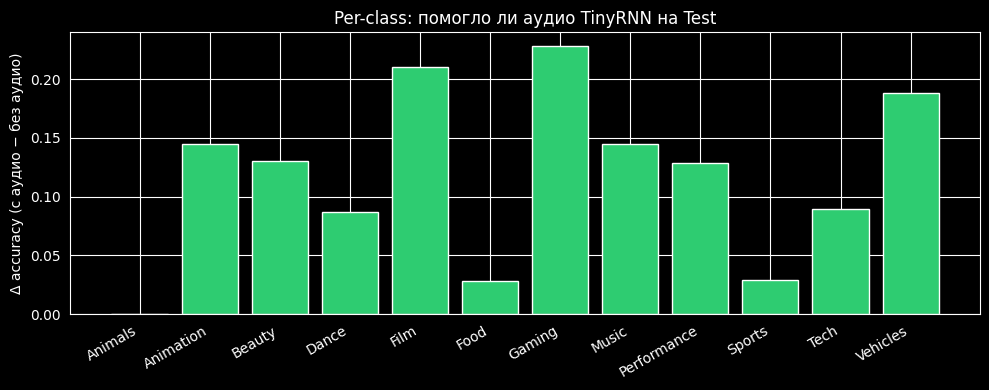

Жанры где аудио помогает: ['Animation', 'Beauty', 'Dance', 'Film', 'Food', 'Gaming', 'Music', 'Performance', 'Sports', 'Tech', 'Vehicles']
Жанры где аудио мешает:   []


In [27]:
# ============================================================
# 12 — Per-class анализ: где аудио помогло, где помешало
# ============================================================
import matplotlib.pyplot as plt

delta_per_class = []
for c, genre in enumerate(GENRES):
    mask    = (t_test == c)
    if mask.sum() == 0:
        delta_per_class.append(0.0)
        continue
    a_no  = (p_no_test[mask]  == c).mean()
    a_yes = (p_yes_test[mask] == c).mean()
    a_g   = (p_gated_test[mask] == c).mean()
    delta_per_class.append(float(a_yes - a_no))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in delta_per_class]
ax.bar(GENRES, delta_per_class, color=colors)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel('Δ accuracy (с аудио − без аудио)')
ax.set_title('Per-class: помогло ли аудио TinyRNN на Test')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Жанры где аудио помогает:', [g for g, d in zip(GENRES, delta_per_class) if d > 0])
print('Жанры где аудио мешает:  ', [g for g, d in zip(GENRES, delta_per_class) if d < 0])

## Схема финальной архитектуры

```
                  ┌──────────────┐
  audio_frames ──►│ AudioGateNet │──► gate (0 или 1)
                  └──────────────┘         │
                                           │
  audio_frames ─────────────────────── × gate ──┐
                                                 │
  rgb_frames ──────────────────────────────────►concat──► GRU ──► head ──► класс
                                                 │
  gate_scalar ────────────────────────────────►  ┘  (добавляется к hidden перед head)
```

Если `gate=0` → аудио обнуляется, классификатор знает об этом через `gate_scalar=0`.
Если `gate=1` → аудио подаётся как обычно.

## Cross-Modal Attention (Flamingo/BLIP-2 style)

Вместо бинарного gate — **cross-attention**: каждый RGB-кадр сам решает, сколько брать из аудио в этот момент времени.

```
RGB  (B, L, 1024) ──► proj_rgb ──► Query  ─┐
                                             ├─► MultiheadAttention ──► residual+norm ──► GRU ──► head
Audio(B, L, 128)  ──► proj_aud ──► Key,Val ─┘
```

Два ключевых улучшения над GatedRNN:
1. **Shared projection space** — обе модальности в одном 256-мерном пространстве перед fusion
2. **Modality dropout** — 30% времени во время обучения аудио обнуляется; модель учится работать без него и не полагаться на шум

Всё тренируется сквозным градиентом — никаких псевдо-меток.

In [ ]:
# ============================================================
# 13 — CrossModalRNN: архитектура
# ============================================================
class CrossModalRNN(nn.Module):
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=256, num_heads=4,
                 rnn_hidden=256, rnn_layers=1, dropout=0.3):
        super().__init__()
        # Shared embedding space — обе модальности в одном пространстве
        self.proj_rgb = nn.Sequential(
            nn.Linear(dim_rgb, proj_dim), nn.LayerNorm(proj_dim), nn.GELU(),
        )
        self.proj_aud = nn.Sequential(
            nn.Linear(dim_aud, proj_dim), nn.LayerNorm(proj_dim), nn.GELU(),
        )
        # Cross-modal attention: RGB (query) ← Audio (key/value)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(proj_dim)
        self.attn_drop = nn.Dropout(dropout)

        # GRU на обогащённой последовательности
        self.rnn = nn.GRU(
            proj_dim, rnn_hidden, num_layers=rnn_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(rnn_hidden * 2),
            nn.Dropout(dropout),
            nn.Linear(rnn_hidden * 2, n_classes),
        )

    def forward(self, rgb, aud, lengths, mod_dropout_p=0.0):
        B, L, _ = rgb.shape

        # Modality dropout: обнуляем аудио для случайных примеров
        if self.training and mod_dropout_p > 0:
            drop_mask = torch.rand(B, 1, 1, device=rgb.device) < mod_dropout_p
            aud = aud.masked_fill(drop_mask, 0.0)

        # Проецируем в общее пространство
        q = self.proj_rgb(rgb)   # (B, L, D)  — запросы из RGB
        k = self.proj_aud(aud)   # (B, L, D)  — ключи и значения из аудио

        # lengths может прийти на CPU из DataLoader — явно переносим
        pad_mask = torch.arange(L, device=rgb.device).unsqueeze(0) >= lengths.to(rgb.device).unsqueeze(1)

        # RGB смотрит на аудио через cross-attention
        attended, _ = self.cross_attn(q, k, k, key_padding_mask=pad_mask)

        # Residual + norm (как в трансформере)
        x = self.attn_norm(q + self.attn_drop(attended))  # (B, L, D)

        # GRU
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        h = torch.cat([h[-2], h[-1]], dim=-1)  # (B, 2H)

        return self.head(h)


nparams = sum(p.numel() for p in CrossModalRNN(DIM_RGB, DIM_AUD, N_CLASSES).parameters())
print(f'CrossModalRNN params: {nparams/1e6:.2f}M')
print(f'(GatedRNN было:        {sum(p.numel() for p in GatedRNN(DIM_RGB, DIM_AUD, N_CLASSES).parameters())/1e6:.2f}M)')

In [29]:
# ============================================================
# 14 — Обучение CrossModalRNN с modality dropout
# ============================================================
MOD_DROPOUT_P = 0.3   # 30% примеров — без аудио во время обучения
EPOCHS_CM     = 20

cross_model = CrossModalRNN(DIM_RGB, DIM_AUD, N_CLASSES).to(DEVICE)
tr_cm, va_cm, te_cm = make_loaders(use_audio=True, batch_size=256)

opt_cm   = torch.optim.AdamW(cross_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched_cm = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cm, T_max=EPOCHS_CM)
crit_cm  = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_cm, best_state_cm = 0.0, None

for ep in range(1, EPOCHS_CM + 1):
    cross_model.train()
    for rgb, aud, T, yi in tr_cm:
        rgb, aud, T, yi = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE), yi.to(DEVICE)
        opt_cm.zero_grad()
        logits = cross_model(rgb, aud, T, mod_dropout_p=MOD_DROPOUT_P)
        crit_cm(logits, yi).backward()
        nn.utils.clip_grad_norm_(cross_model.parameters(), 1.0)
        opt_cm.step()
    sched_cm.step()

    cross_model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for rgb, aud, T, yi in va_cm:
            rgb, aud, T = rgb.to(DEVICE), aud.to(DEVICE), T.to(DEVICE)
            p = cross_model(rgb, aud, T).argmax(1).cpu().numpy()
            preds.extend(p); trues.extend(yi.numpy())
    val_acc = accuracy_score(trues, preds)
    if val_acc > best_val_cm:
        best_val_cm = val_acc
        best_state_cm = {k: v.clone() for k, v in cross_model.state_dict().items()}
    if ep % 5 == 0:
        print(f'  [cross_modal] ep {ep:>2}/{EPOCHS_CM}  val_acc={val_acc:.4f}')

cross_model.load_state_dict(best_state_cm)
print(f'CrossModalRNN best val_acc={best_val_cm:.4f}')

STAGE5_DIR = Path('../data2/frame_stage5')
STAGE5_DIR.mkdir(parents=True, exist_ok=True)
torch.save(cross_model.state_dict(), STAGE5_DIR / 'best_cross_modal.pt')
print(f'Сохранено → {STAGE5_DIR}/best_cross_modal.pt')

  [cross_modal] ep  5/20  val_acc=0.6829
  [cross_modal] ep 10/20  val_acc=0.6707
  [cross_modal] ep 15/20  val_acc=0.6599
  [cross_modal] ep 20/20  val_acc=0.6640
CrossModalRNN best val_acc=0.6829
Сохранено → ../data2/frame_stage5/best_cross_modal.pt


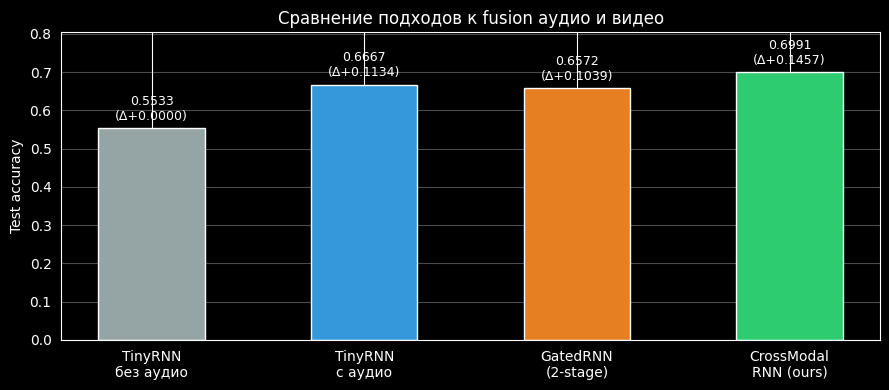

  TinyRNN без аудио  : 0.5533  (baseline)
  TinyRNN с аудио    : 0.6667  Δ=+0.1134
  GatedRNN (2-stage) : 0.6572  Δ=+0.1039
  CrossModalRNN      : 0.6991  Δ=+0.1457

Лучшая модель: CrossModal RNN (ours) (0.6991)


In [30]:
# ============================================================
# 15 — Итоговое сравнение всех подходов
# ============================================================
import matplotlib.pyplot as plt

p_cm_test, _ = eval_on_test(cross_model, te_cm, is_gated=False)
acc_cm = accuracy_score(t_test, p_cm_test)

models  = ['TinyRNN\nбез аудио', 'TinyRNN\nс аудио', 'GatedRNN\n(2-stage)', 'CrossModal\nRNN (ours)']
accs    = [acc_no, acc_yes, acc_g, acc_cm]
colors  = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']
deltas  = [0, acc_yes - acc_no, acc_g - acc_no, acc_cm - acc_no]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(models, accs, color=colors, width=0.5, zorder=2)
ax.bar_label(bars, [f'{a:.4f}\n(Δ{d:+.4f})' for a, d in zip(accs, deltas)],
             padding=4, fontsize=9)
ax.set_ylim(0, max(accs) * 1.15)
ax.set_ylabel('Test accuracy')
ax.set_title('Сравнение подходов к fusion аудио и видео')
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

print('=' * 50)
print(f'  TinyRNN без аудио  : {acc_no:.4f}  (baseline)')
print(f'  TinyRNN с аудио    : {acc_yes:.4f}  Δ={acc_yes-acc_no:+.4f}')
print(f'  GatedRNN (2-stage) : {acc_g:.4f}  Δ={acc_g-acc_no:+.4f}')
print(f'  CrossModalRNN      : {acc_cm:.4f}  Δ={acc_cm-acc_no:+.4f}')
print('=' * 50)

best = max(acc_no, acc_yes, acc_g, acc_cm)
winner = models[accs.index(best)].replace('\n', ' ')
print(f'\nЛучшая модель: {winner} ({best:.4f})')